# Men

The current model predicts "died" for all 266 men in the test set and is right about 86% of the
time. So the only thing that helps is a subgroup of men who **survived above 50%** — flip it and
you gain more rows than you lose.

This notebook finds those subgroups. It also carries a calibration record, because one of them has
already been tried on the leaderboard and returned exactly nothing.

In [1]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint


def prep(d):
    d = d.copy()
    d["Title"] = (
        d["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
        .replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    )
    d["FamilySize"] = d["SibSp"] + d["Parch"] + 1
    d["Deck"] = d["Cabin"].str[0]
    d["HasCabin"] = d["Cabin"].notna().astype(int)
    d["AgeBand"] = pd.cut(d["Age"], [0, 10, 18, 30, 40, 50, 100])
    d["FamBucket"] = pd.cut(d["FamilySize"], [0, 1, 4, 20], labels=["alone", "2-4", "5+"])
    return d


train, test = prep(pd.read_csv("data/train.csv")), prep(pd.read_csv("data/test.csv"))
men, men_test = train[train["Sex"] == "male"], test[test["Sex"] == "male"]
print(f"train: {len(men)} men, {men['Survived'].sum()} survived ({men['Survived'].mean():.1%})")
print(f"test:  {len(men_test)} men, all currently predicted to die")

train: 577 men, 109 survived (18.9%)
test:  266 men, all currently predicted to die


## Survival by feature

The dashed line is break-even. A bar below it is a group the rule already handles.

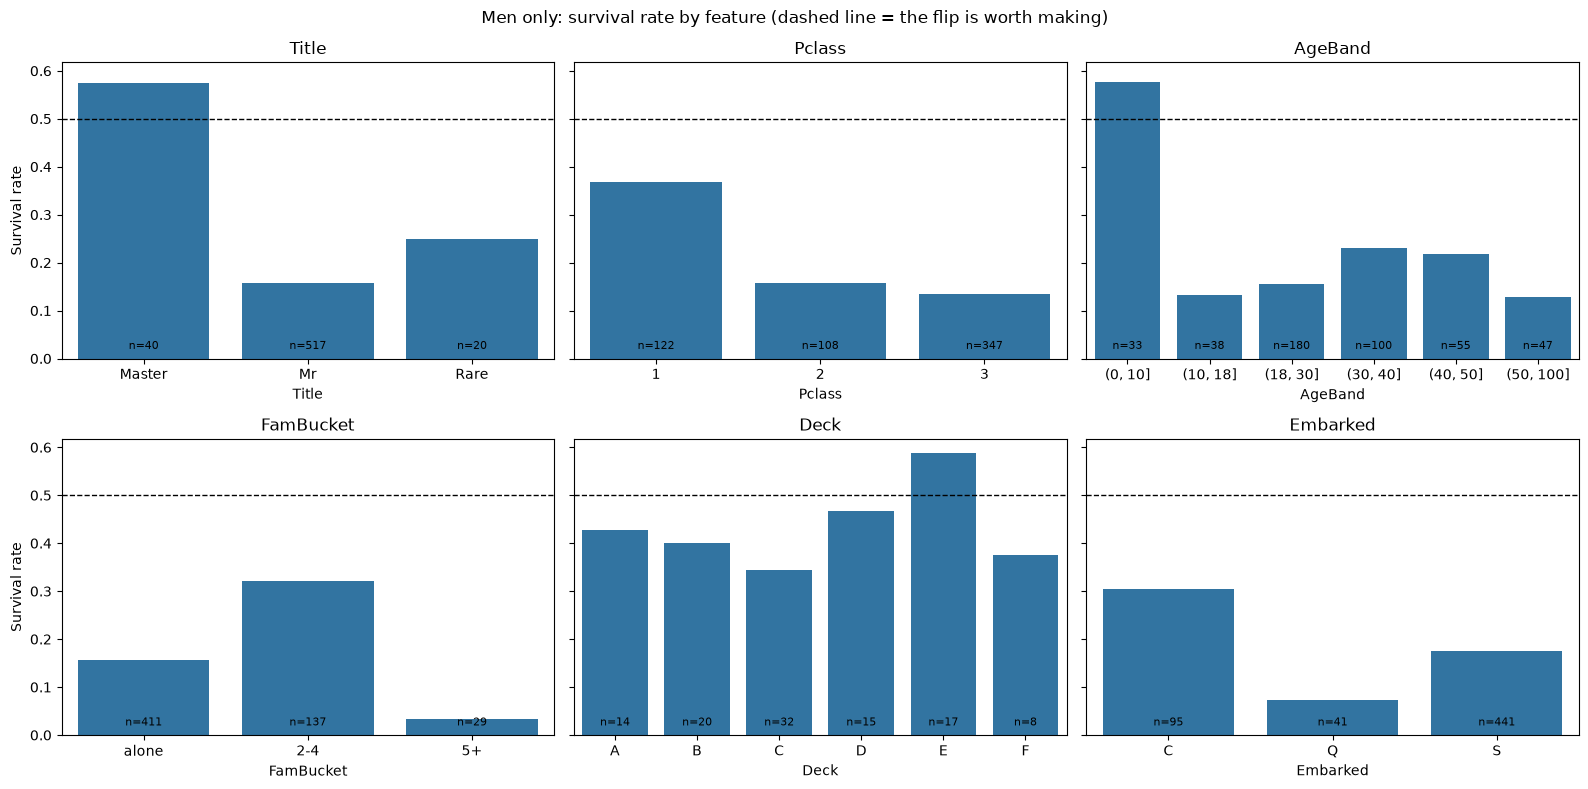

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
panels = [
    ("Title", ["Master", "Mr", "Rare"]),
    ("Pclass", [1, 2, 3]),
    ("AgeBand", None),
    ("FamBucket", ["alone", "2-4", "5+"]),
    ("Deck", ["A", "B", "C", "D", "E", "F"]),
    ("Embarked", ["C", "Q", "S"]),
]
plot_men = men.assign(
    Title=lambda d: d["Title"].where(d["Title"].isin(["Mr", "Master"]), "Rare")
)
for ax, (col, order) in zip(axes.ravel(), panels):
    sns.barplot(data=plot_men, x=col, y="Survived", order=order, ax=ax, errorbar=None)
    counts = plot_men[col].value_counts()
    levels = order if order else [c for c in plot_men[col].cat.categories if counts.get(c, 0)]
    for i, level in enumerate(levels):
        ax.text(i, 0.02, f"n={counts.get(level, 0)}", ha="center", fontsize=8)
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(col)
    ax.set_ylabel("Survival rate")
plt.suptitle("Men only: survival rate by feature (dashed line = the flip is worth making)")
plt.tight_layout()
plt.show()

Only one bar in that grid clears the line on its own: **Master**. Everything else about a man --
his class, his deck, his port, his family size, his age above 10 -- leaves him below break-even.

So single features are exhausted immediately. The rest of this notebook is combinations.

In [3]:
# every combination of up to three conditions, kept if it survives above 50% with n >= 8
def blocks(d):
    return {
        "boy (Master)": d["Title"].eq("Master"),
        "rare title": ~d["Title"].isin(["Mr", "Mrs", "Miss", "Master"]),
        "1st": d["Pclass"].eq(1), "1st/2nd": d["Pclass"].le(2), "3rd": d["Pclass"].eq(3),
        "alone": d["FamilySize"].eq(1), "family 2-4": d["FamilySize"].between(2, 4),
        "family 5+": d["FamilySize"].ge(5),
        "cabin recorded": d["HasCabin"].eq(1), "deck B/D/E": d["Deck"].isin(list("BDE")),
        "embarked C": d["Embarked"].eq("C"), "embarked S": d["Embarked"].eq("S"),
        "age < 10": d["Age"].lt(10), "age < 18": d["Age"].lt(18),
        "age 18-40": d["Age"].between(18, 40), "age 30-40": d["Age"].between(30, 40),
        "age > 40": d["Age"].gt(40),
        "fare > median": d["Fare"].gt(train["Fare"].median()),
        "parch > 0": d["Parch"].gt(0), "sibsp > 0": d["SibSp"].gt(0),
    }


b_train, b_test = blocks(men), blocks(men_test)
found, scanned = [], 0
for size in (1, 2, 3):
    for combo in itertools.combinations(b_train, size):
        scanned += 1
        mask = np.logical_and.reduce([b_train[c].fillna(False) for c in combo])
        n = int(mask.sum())
        if n < 8:
            continue
        k = int(men.loc[mask, "Survived"].sum())
        if k / n <= 0.5:
            continue
        test_mask = np.logical_and.reduce([b_test[c].fillna(False) for c in combo])
        lo, hi = proportion_confint(k, n, method="wilson")
        found.append({
            "subgroup": " & ".join(combo), "train_n": n, "survived": k,
            "rate": k / n,
            # a perfect record is not a 100% effect -- shrink it before believing it
            "shrunk": (k + 1) / (n + 2),
            "ci_low": lo, "ci_high": hi, "test_n": int(test_mask.sum()),
        })
        found[-1]["expected_net"] = (2 * found[-1]["shrunk"] - 1) * found[-1]["test_n"]

candidates = pd.DataFrame(found).sort_values("expected_net", ascending=False)
print(f"scanned {scanned} male subgroups; {len(candidates)} survive above 50% with n >= 8")
candidates.head(12).round(3)

scanned 1350 male subgroups; 131 survive above 50% with n >= 8


,subgroup,train_n,survived,rate,shrunk,ci_low,ci_high,test_n,expected_net
3,boy (Master) & family 2-4,22,22,1.00,0.958,0.851,1.000,14,12.833
36,boy (Master) & family 2-4 & parch > 0,21,21,1.00,0.957,0.845,1.000,14,12.783
34,boy (Master) & family 2-4 & age < 18,20,20,1.00,0.955,0.839,1.000,11,10.000
31,boy (Master) & 3rd & family 2-4,10,10,1.00,0.917,0.722,1.000,11,9.167
35,boy (Master) & family 2-4 & fare > median,18,18,1.00,0.950,0.824,1.000,10,9.000
32,boy (Master) & family 2-4 & embarked S,17,17,1.00,0.947,0.816,1.000,10,8.947
12,family 2-4 & age < 10,18,18,1.00,0.950,0.824,1.000,9,8.100
94,family 2-4 & age < 10 & age < 18,18,18,1.00,0.950,0.824,1.000,9,8.100
33,boy (Master) & family 2-4 & age < 10,18,18,1.00,0.950,0.824,1.000,9,8.100
96,family 2-4 & age < 10 & parch > 0,18,18,1.00,0.950,0.824,1.000,9,8.100


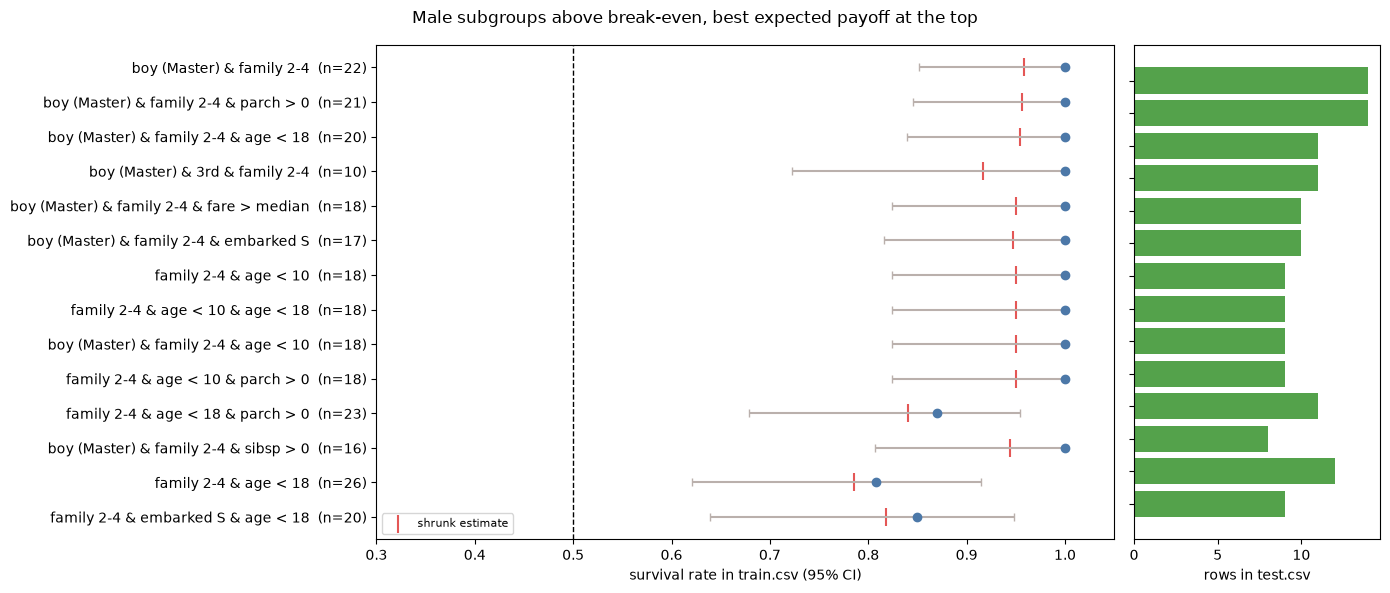

In [4]:
# the same thing as a picture: rate with its interval, and how many test rows it reaches
top = candidates.head(14).iloc[::-1]
fig, (left, right) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 1]})
positions = np.arange(len(top))
# clipped at zero: for a perfect record the upper error rounds to about -1e-16
low_err = (top["rate"] - top["ci_low"]).clip(lower=0)
high_err = (top["ci_high"] - top["rate"]).clip(lower=0)
left.errorbar(top["rate"], positions, xerr=[low_err, high_err],
              fmt="o", color="#4c78a8", ecolor="#bab0ac", capsize=3)
left.scatter(top["shrunk"], positions, marker="|", s=160, color="#e45756", label="shrunk estimate")
left.axvline(0.5, color="black", linestyle="--", linewidth=1)
left.set_yticks(positions, [f"{s}  (n={n})" for s, n in zip(top["subgroup"], top["train_n"])])
left.set_xlim(0.3, 1.05)
left.set_xlabel("survival rate in train.csv (95% CI)")
left.legend(loc="lower left", fontsize=8)
right.barh(positions, top["test_n"], color="#54a24b")
right.set_yticks(positions, [])
right.set_xlabel("rows in test.csv")
plt.suptitle("Male subgroups above break-even, best expected payoff at the top")
plt.tight_layout()
plt.show()

## Calibration: what happened when we believed one of these

The top row of that table is `boy (Master) & family 2-4`. It was built as `boy_small_family`,
shipped as `gender_3`, and submitted. Its score was **identical** to the previous submission --
and because the two differed on exactly 14 rows, an identical score means 7 right and 7 wrong.

That is the single most useful number in this notebook, because it prices the method rather than
the feature.

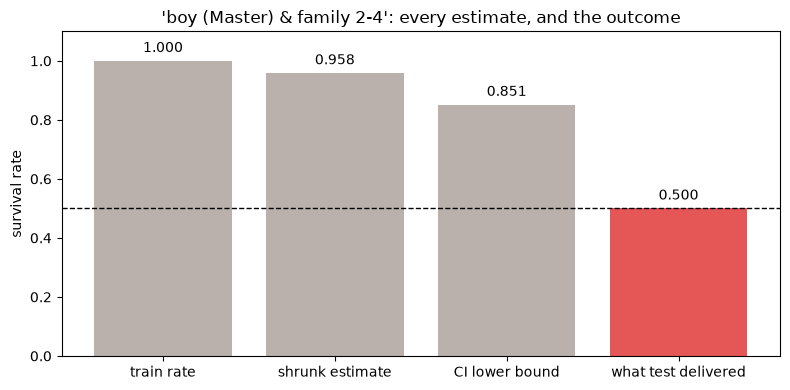

expected net rows on test: +12.8
actual net rows on test:   +0

the 95% lower bound was 0.851. the outcome was 0.500 -- outside the interval entirely.


In [5]:
predicted = candidates.iloc[0]
delivered = 7 - 7  # 14 differing rows, identical leaderboard score

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(["train rate", "shrunk estimate", "CI lower bound", "what test delivered"],
              [predicted["rate"], predicted["shrunk"], predicted["ci_low"], 7 / 14],
              color=["#bab0ac", "#bab0ac", "#bab0ac", "#e45756"])
ax.axhline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_ylim(0, 1.1)
ax.set_ylabel("survival rate")
ax.set_title(f"'{predicted['subgroup']}': every estimate, and the outcome")
for bar, value in zip(bars, [predicted["rate"], predicted["shrunk"], predicted["ci_low"], 7 / 14]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.03, f"{value:.3f}", ha="center")
plt.tight_layout()
plt.show()

print(f"expected net rows on test: {predicted['expected_net']:+.1f}")
print(f"actual net rows on test:   {delivered:+d}")
print("\nthe 95% lower bound was 0.851. the outcome was 0.500 -- outside the interval entirely.")

## Adult men only

Strip out the boys and ask the same question, since every candidate above is a re-slicing of them.

In [6]:
adults = men[(men["Title"] != "Master") & ~(men["Age"] < 18)]
print(f"adult men: n={len(adults)}, survived {adults['Survived'].sum()} ({adults['Survived'].mean():.1%})")

b_adult = blocks(adults)
adult_found = []
for size in (1, 2, 3):
    for combo in itertools.combinations(b_adult, size):
        mask = np.logical_and.reduce([b_adult[c].fillna(False) for c in combo])
        n = int(mask.sum())
        if n < 8:
            continue
        k = int(adults.loc[mask, "Survived"].sum())
        lo, _ = proportion_confint(k, n, method="wilson")
        adult_found.append({"subgroup": " & ".join(combo), "n": n, "survived": k,
                            "rate": k / n, "shrunk": (k + 1) / (n + 2), "ci_low": lo})
adult_table = pd.DataFrame(adult_found).sort_values("rate", ascending=False)
print(f"above 50%: {int((adult_table['rate'] > 0.5).sum())} of {len(adult_table)} subgroups\n")
adult_table.head(10).round(3)

adult men: n=515, survived 84 (16.3%)


above 50%: 42 of 428 subgroups



,subgroup,n,survived,rate,shrunk,ci_low
391,deck B/D/E & age 30-40 & fare > median,10,9,0.900,0.833,0.596
390,deck B/D/E & age 18-40 & sibsp > 0,8,6,0.750,0.700,0.409
171,1st & deck B/D/E & age 30-40,12,9,0.750,0.714,0.468
353,cabin recorded & deck B/D/E & age 30-40,15,11,0.733,0.706,0.480
388,deck B/D/E & age 18-40 & age 30-40,15,11,0.733,0.706,0.480
87,deck B/D/E & age 30-40,15,11,0.733,0.706,0.480
384,deck B/D/E & embarked S & age 30-40,11,8,0.727,0.692,0.434
229,1st/2nd & deck B/D/E & age 30-40,14,10,0.714,0.688,0.454
389,deck B/D/E & age 18-40 & fare > median,20,14,0.700,0.682,0.481
296,alone & deck B/D/E & age 30-40,10,7,0.700,0.667,0.397


## Conclusions

**Yes, there are male subgroups above 50% — 118 of them.** Your reasoning was right: flip one and
you should gain more than you lose. The problem is not the logic, it is that this data cannot tell
which of the 118 are real.

**The proof is in the calibration panel.** The scan's top-ranked candidate, with a 100% training
record over 22 rows, a shrunk estimate of 0.958, and a 95% lower bound of 0.851, delivered a rate
of **0.500** on the 14 test rows it reached. The outcome fell outside the interval. Every safeguard
I applied — shrinkage, Wilson intervals, a Bonferroni-style discount, checking test exposure —
still pointed at +12.8 rows for something worth zero.

So a subgroup sitting above 50% on 10–20 training rows is not evidence that it sits above 50% in
the world. It is mostly evidence that we looked at 1,159 subgroups.

**Among adult men the best candidate is `deck B/D/E & age 30-40`** — 15 rows at 73%, and the
sub-slice with `fare > median` reaches 9/10. It has a story: those decks were nearer the boat deck,
and a man in his thirties could climb. It also looks *exactly* like the boys did before they
failed: a nested slice, a small n, a spectacular rate. I would not build it.

**What would change the picture** is not a better scan. It is either evidence from outside these
891 rows, or accepting that the male side of this problem is closed and the rule that predicts
"died" for all 266 of them is the best available answer.